In [1]:
import os
from dotenv import load_dotenv
from typing import Annotated
from langchain_core.messages import HumanMessage, BaseMessage, AIMessage, ToolMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from typing_extensions import TypedDict
import json

load_dotenv()  # loads BLABLADOR_API_KEY from .env

from langchain_mcp_adapters.client import MultiServerMCPClient
from agentevals.trajectory.match import create_trajectory_match_evaluator



# import asyncio
# from langchain_mcp_adapters.client import MultiServerMCPClient  

# Or set directly (not recommended for shared notebooks):
# os.environ["BLABLADOR_API_KEY"] = "your_key_here"

Loaded 8 tools: ['get_current_time', 'unit_converter', 'search_web', 'text_stats', 'calculator', 'get_weather', 'ask_rdm', 'search_rdm']
Model ready.
Graph compiled successfully.


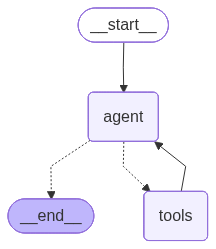

Q: What is (123 * 456) + 789?
A: {'answer': '\n\n(123 * 456) + 789 = 56,877.', 'messages': [HumanMessage(content='What is (123 * 456) + 789?', additional_kwargs={}, response_metadata={}, id='733b1475-38b5-4c63-aad3-d9f6b3f761d7'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 145, 'prompt_tokens': 928, 'total_tokens': 1073, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': '02 - Qwen3.5-122B-A10B-FP8, general purpose large model', 'system_fingerprint': None, 'id': 'chatcmpl-0dd1dea7-d567-47d7-9000-1c7ad19ee46b', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e89bd-5283-7841-9908-24e8fb90bf67-0', tool_calls=[{'name': 'calculator', 'args': {'expression': '(123 * 456) + 789'}, 'id': 'chatcmpl-tool-84d0009726b9f35d', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 928, 'output_tokens': 145, 'total_tokens': 1073, 'inp

In [4]:
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

BLABLADOR_BASE_URL = "https://api.helmholtz-blablador.fz-juelich.de/v1"

with open("mcp_config.json") as f:
    config = json.load(f)

    client = MultiServerMCPClient(config)
    tools = await client.get_tools()
    print(f"Loaded {len(tools)} tools: {[t.name for t in tools]}")

    llm = ChatOpenAI(
        model="alias-large",
        base_url=BLABLADOR_BASE_URL,
        api_key=os.getenv("BLABLADOR_API_KEY"),
    )
    llm_with_tools = llm.bind_tools(tools)
    print("Model ready.")

    async def agent_node(state: AgentState) -> AgentState:
        response = await llm_with_tools.ainvoke(state["messages"])  # must await
        return {"messages": [response]}

    def build_graph():
        graph = StateGraph(AgentState)
        graph.add_node("agent", agent_node)
        graph.add_node("tools", ToolNode(tools))
        graph.add_edge(START, "agent")
        graph.add_conditional_edges("agent", tools_condition)
        graph.add_edge("tools", "agent")
        return graph.compile()

    app = build_graph()
    print("Graph compiled successfully.")

    try:
        from IPython.display import Image, display
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception:
        print(app.get_graph().draw_mermaid())
    
    async def run_with_trajectory(user_input: str) -> dict:
        result = await app.ainvoke({"messages": [HumanMessage(content=user_input)]})
        return {
            "answer": result["messages"][-1].content,
            "messages": result["messages"]  # full trajectory
        }

    queries = [
        "What is (123 * 456) + 789?",
        "What's the weather in Tokyo?",
        "What is 100 divided by 4, and what's the weather in New York?",
        "What are the UFZ guidelines for long-term archiving?",
    ]

    for q in queries:
        print(f"Q: {q}")
        print(f"A: {await run_with_trajectory(q)}")   # must await async run()
        print()

In [5]:
# Example for: "What is (123 * 456) + 789?"
expected_math = [
    HumanMessage(content="What is (123 * 456) + 789?"),
    AIMessage(
        content="",
        tool_calls=[{
            "name": "calculator",        # the tool your agent should call
            "args": {"expression": "(123 * 456) + 789"},
            "id": "call_001"
        }]
    ),
    ToolMessage(content="56877", tool_call_id="call_001"),
    AIMessage(content="The result is 56,877."),
]

# Example for: "What's the weather in Tokyo?"
expected_weather = [
    HumanMessage(content="What's the weather in Tokyo?"),
    AIMessage(
        content="",
        tool_calls=[{
            "name": "get_weather",
            "args": {"city": "Tokyo"},
            "id": "call_002"
        }]
    ),
    ToolMessage(content="Sunny, 28°C", tool_call_id="call_002"),
    AIMessage(content="The weather in Tokyo is sunny and 28°C."),
]

In [6]:
evaluator = create_trajectory_match_evaluator(trajectory_match_mode="subset")

test_cases = [
    ("What is (123 * 456) + 789?",          expected_math),
    ("What's the weather in Tokyo?",          expected_weather),
    # add more as you build golden trajectories
]

results = []
for query, expected_messages in test_cases:
    output = await run_with_trajectory(query)
    result = evaluator(
        outputs={"messages": output["messages"]},
        reference_outputs={"messages": expected_messages}
    )
    results.append({
        "query": query,
        "passed": result["score"],
        "actual_tools": [
            m.tool_calls[0]["name"]
            for m in output["messages"]
            if hasattr(m, "tool_calls") and m.tool_calls
        ],
    })

for r in results:
    status = "✅" if r["passed"] else "❌"
    print(f"{status} {r['query']}")
    print(f"   Tools used: {r['actual_tools']}")

✅ What is (123 * 456) + 789?
   Tools used: ['calculator']
✅ What's the weather in Tokyo?
   Tools used: ['get_weather']
